# **M 21 - Projeto de Credit Score - Árvore de Decisão**


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

df = pd.read_csv("dados_tratados.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [23]:
# Define a variável-alvo
target_col = 'Credit Score'

# Separa X (características) e y (target)
X = df.drop(columns=[target_col])
y = df[target_col]

# Divide em treino e teste (70% treino, 30% teste) mantendo proporções de y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Verifica se o número de linhas condiz
print(f'Dimensões de X_train: {X_train.shape}')
print(f'Dimensões de y_train: {y_train.shape}')
print(f'Dimensões de X_test: {X_test.shape}')
print(f'Dimensões de y_test: {y_test.shape}')

# Confere se apenas a coluna de score está em y e todas as demais em X
print(f'Colunas usadas como variáveis explicativas (X): {X.columns.to_list()}')
print(f'Coluna usada como variável-alvo (y): {y.name}')

# Verifica se o y do conjunto de teste está balanceado
teste_counts = y_test.value_counts()
teste_proportion = y_test.value_counts(normalize=True)

print('Distribuição de classes em y_test:')
print(teste_counts)
print('\\nProporções em y_test:')
print(teste_proportion)


Dimensões de X_train: (114, 7)
Dimensões de y_train: (114,)
Dimensões de X_test: (50, 7)
Dimensões de y_test: (50,)
Colunas usadas como variáveis explicativas (X): ['Age', 'Gender', 'Income', 'Education', 'Marital Status', 'Number of Children', 'Home Ownership']
Coluna usada como variável-alvo (y): Credit Score
Distribuição de classes em y_test:
Credit Score
High       34
Average    11
Low         5
Name: count, dtype: int64
\nProporções em y_test:
Credit Score
High       0.68
Average    0.22
Low        0.10
Name: proportion, dtype: float64


# 2) Qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Aplicar um algoritmo de Árvore de Decisão é como construir um mapa lógico para a tomada de decisões automáticas. Diferente de outros modelos de, sua grande vantagem reside na transparência: ele segmenta os dados em subconjuntos cada vez mais específicos, criando uma estrutura fácil de interpretar. Para que esse processo seja eficiente, seguimos um fluxo estruturado conforme os passos abaixo:

1. Preparação e Refino dos Dados - 
O sucesso de qualquer modelo nasce na qualidade dos dados. Antes de ensinar a máquina, precisamos realizar uma limpeza, tratando valores nulos e corrigindo inconsistências. Como os algoritmos de machine learning preferem números a palavras, variáveis categóricas devem ser transformadas via técnicas como Label Encoding ou One-Hot Encoding. Por fim, isolamos as variáveis explicativas da variável alvo.

3. A Divisão Estratégica - 
Para saber se o modelo realmente aprendeu ou se apenas decorou os dados, dividimos a base em dois conjuntos distintos: treino e teste. Geralmente, utiliza-se a proporção de 70/30. O conjunto de treino serve para a construção das regras, enquanto o de teste funciona como um exame final, avaliando a capacidade do algoritmo de lidar com informações inéditas e generalizar o conhecimento.


5. O Treinamento e a Lógica da Árvore - 
Durante o treinamento, o algoritmo busca as variáveis que melhor separam as classes. Ele utiliza critérios matemáticos, como o Índice de Gini ou a Entropia, para medir a pureza de cada divisão. A estrutura começa em um "nó raiz", desdobra-se em "nós intermediários" e termina nas "folhas", que representam a classificação final do objeto de estudo.


7. Testando as Premissas - 
Com a árvore devidamente estruturada, submetemos o conjunto de teste ao modelo. Nesta fase, o algoritmo não conhece as respostas reais, ele apenas aplica as regras que criou no passo anterior para realizar suas previsões.


9. Avaliação de Performance - 
A última etapa consiste em confrontar o que o modelo previu com a realidade. A ferramenta clássica aqui é a Matriz de Confusão, que revela detalhadamente onde o modelo acertou e onde confundiu as classes. Para uma análise mais profunda, especialmente em cenários onde os dados são desbalanceados, recorremos a métricas como Precision, Recall e F1-score, garantindo que a solução seja robusta e confiável para o uso prático.

Como práticas de melhoria, usamos a poda da árvore, evitando o overfitting. Removendo dispersões pouco relevantes e mantendo somente o que mais impacta na nossa decisão e para chegarmos na melhor variável alvo possivel.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [25]:
# COPIAR AS BASES ORIGINAIS PARA EVITAR MODIFICÁ-LAS
X_train_pre = X_train.copy()
X_test_pre  = X_test.copy()

# 1. CONVERTE 'Age' PARA NUMÉRICO E TRATA VALORES AUSENTES
X_train_pre['Age'] = pd.to_numeric(X_train_pre['Age'], errors='coerce')
X_test_pre['Age']  = pd.to_numeric(X_test_pre['Age'],  errors='coerce')

# Preenche valores ausentes com a mediana da idade de treino
median_age = X_train_pre['Age'].median()
X_train_pre['Age'] = X_train_pre['Age'].fillna(median_age)
X_test_pre['Age']  = X_test_pre['Age'].fillna(median_age)

# 2. CONVERTE 'Income' PARA FLOAT
def parse_income(series):
    """Converte valores de renda armazenados como texto (p.ex. '100.000,00')
    para float, e tolera se a série já for numérica."""
    # Se a série já é numérica, apenas retorna com conversão
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    # Caso contrário, converte para string e substitui separadores
    series_str = series.astype(str)
    series_str = series_str.str.replace('.', '', regex=False)  # remove pontos de milhar
    series_str = series_str.str.replace(',', '.', regex=False)  # troca vírgula por ponto
    return pd.to_numeric(series_str, errors='coerce')

X_train_pre['Income'] = parse_income(X_train_pre['Income'])
X_test_pre['Income']  = parse_income(X_test_pre['Income'])

# 3. ONE‑HOT ENCODING PARA VARIÁVEIS CATEGÓRICAS
X_train_enc = pd.get_dummies(X_train_pre, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_pre,  drop_first=True)

# 4. ALINHA AS COLUNAS (evita inconsistências entre treino e teste)
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

# 5. TREINA A ÁRVORE DE DECISÃO COM CRITÉRIO GINI E random_state=0
dt = DecisionTreeClassifier(criterion='gini', random_state=0)
dt.fit(X_train_enc, y_train)

# 6. CALCULA A ACURÁCIA NO CONJUNTO DE TREINO
y_train_pred = dt.predict(X_train_enc)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f'Acurácia no conjunto de treino: {train_accuracy:.4f}')

Acurácia no conjunto de treino: 1.0000


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [9]:
#aplicar modelo ao teste
y_pred_test = modelo.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)

print("Acurácia no teste:", accuracy_test)

#teste de confusão
confusion_matrix(y_test, y_pred_test)

Acurácia no teste: 0.94


array([[11,  0,  0],
       [ 1, 33,  0],
       [ 2,  0,  3]])

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

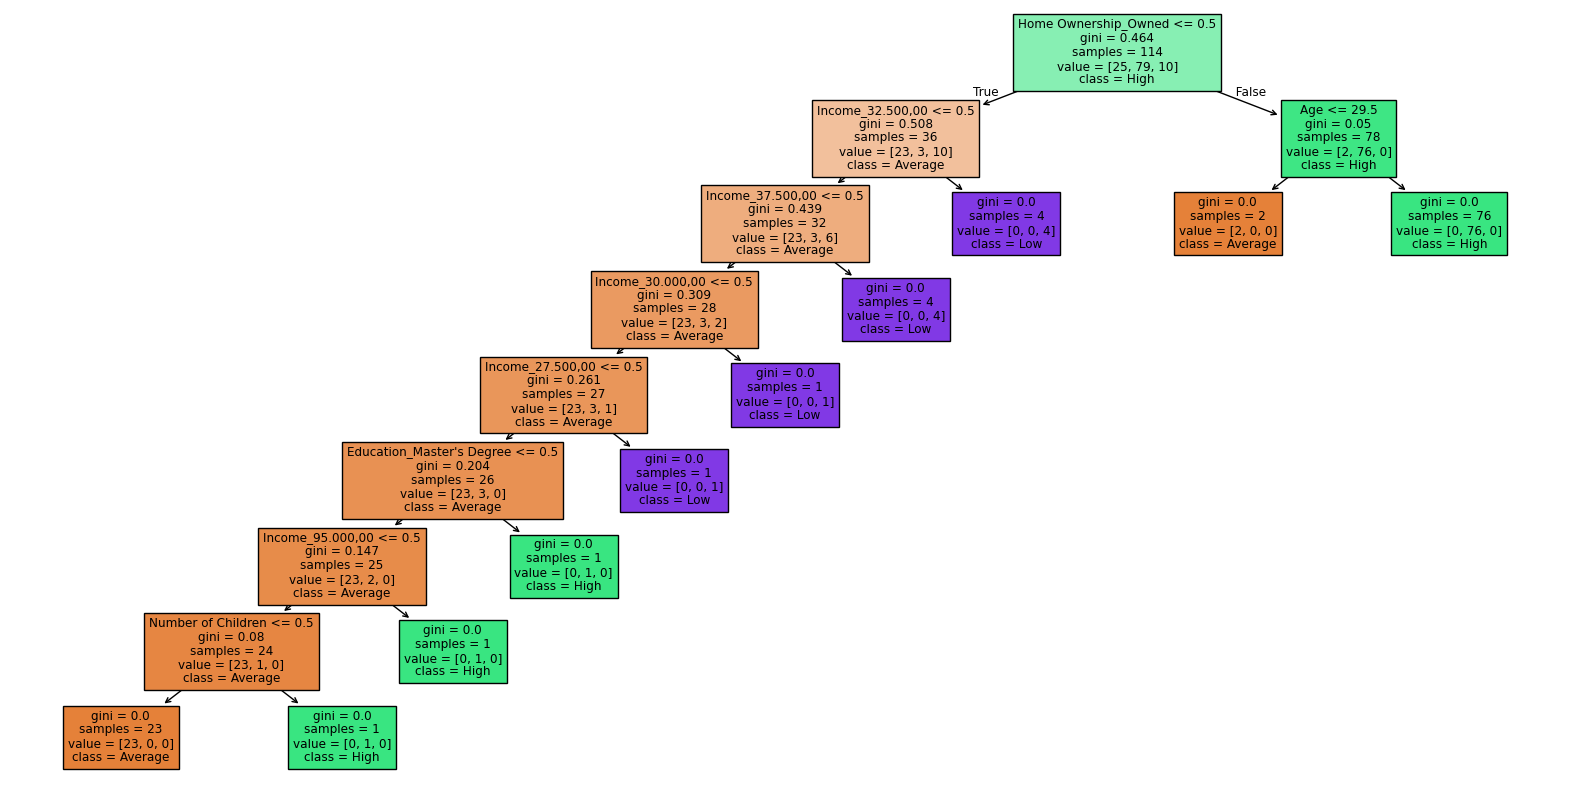

In [10]:
#arvore de decisão

plt.figure(figsize=(20,10))

plot_tree(
    modelo,
    feature_names=X_train.columns,
    class_names=modelo.classes_,
    filled=True
)

plt.show()


É possivel fazer uma avaliação visual da árvore. Esta possui profundidade igual a 8, considerando o caminho mais longo entre o nó raiz e uma folha. Isso significa que o modelo realiza até oito divisões sequenciais nas variáveis para chegar à classificação final do Credit Score.

# 6) Identificando as 2 principais features do modelo.


In [26]:
# DataFrame com as importâncias
df_importancias = pd.DataFrame({
    'Feature': X_train_enc.columns,
    'Importancia': dt.feature_importances_
})

# Ordena e mostra as 2 principais
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)
print(df_importancias.head(2))



                 Feature  Importancia
9  Home Ownership_Rented     0.588557
1                 Income     0.370240


# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

Home Ownership_Rented            0.588557
Income                           0.370240
Age                              0.041203
Number of Children               0.000000
Gender_Male                      0.000000
Education_Bachelor's Degree      0.000000
Education_Doctorate              0.000000
Education_High School Diploma    0.000000
Education_Master's Degree        0.000000
Marital Status_Single            0.000000
dtype: float64
Duas principais features:
Index(['Home Ownership_Rented', 'Income'], dtype='object')
Acurácia treino (Top 2 features): 0.9912280701754386
Acurácia teste (Top 2 features): 0.98


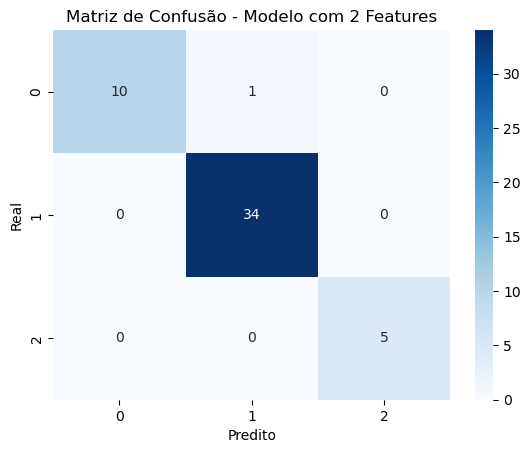

              precision    recall  f1-score   support

     Average       1.00      0.91      0.95        11
        High       0.97      1.00      0.99        34
         Low       1.00      1.00      1.00         5

    accuracy                           0.98        50
   macro avg       0.99      0.97      0.98        50
weighted avg       0.98      0.98      0.98        50



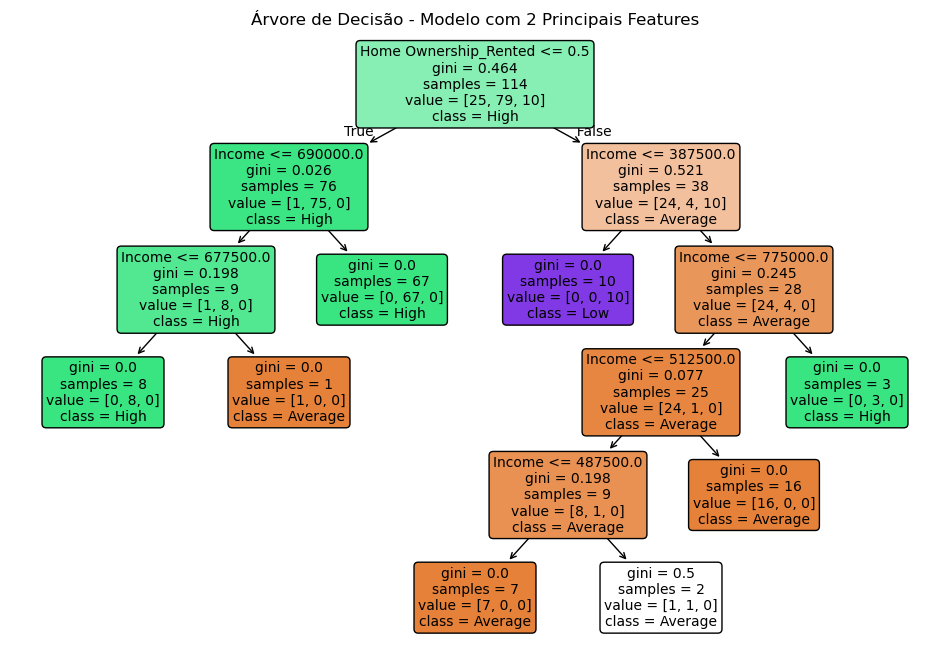

In [29]:
# Calcular importância das variáveis
importancias = pd.Series(dt.feature_importances_, index=X_train_enc.columns)

# Ordenar da maior para a menor
importancias_ordenadas = importancias.sort_values(ascending=False)

# Mostrar as importâncias
print(importancias_ordenadas)

# Identificar as duas principais features
top2_features = importancias_ordenadas.head(2).index

print("Duas principais features:")
print(top2_features)

X_train_top2 = X_train_enc[top2_features]
X_test_top2 = X_test_enc[top2_features]

#treinar as 2 features
dt_top2 = DecisionTreeClassifier(criterion='gini', random_state=0)

dt_top2.fit(X_train_top2, y_train)

#avaliar modelo
# Previsões
y_pred_train_top2 = dt_top2.predict(X_train_top2)
y_pred_test_top2 = dt_top2.predict(X_test_top2)

# Acurácia
acc_train_top2 = accuracy_score(y_train, y_pred_train_top2)
acc_test_top2 = accuracy_score(y_test, y_pred_test_top2)

print("Acurácia treino (Top 2 features):", acc_train_top2)
print("Acurácia teste (Top 2 features):", acc_test_top2)

#matriz de confusão
cm = confusion_matrix(y_test, y_pred_test_top2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo com 2 Features")
plt.show()

#relatorio
print(classification_report(y_test, y_pred_test_top2))

#modelo de arvore com as 2 features
plt.figure(figsize=(12,8))

plot_tree(
    dt_top2,
    feature_names=X_train_top2.columns,
    class_names=dt_top2.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão - Modelo com 2 Principais Features")
plt.show()

Ao priorizar apenas as duas variáveis mais relevantes, ganhamos um modelo significativamente mais simples e interpretável. Essa abordagem facilita a explicação da lógica por trás das decisões, mas geralmente impõe um custo: a perda de nuances que variáveis secundárias poderiam captar.
Na prática, o impacto dessa escolha é revelado pela acurácia. Se o desempenho cair drasticamente, fica claro que o modelo original dependia da combinação de múltiplos fatores para ser preciso. Por outro lado, se a acurácia permanecer estável, confirmamos que essas duas features são o coração do problema, contendo quase toda a informação necessária para uma classificação eficaz.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

O modelo Naive Bayes apresentou melhor desempenho geral e maior estabilidade nas previsões, principalmente por lidar bem com conjuntos de dados menores e com variáveis categóricas. Além disso, possui menor complexidade computacional e menor risco de overfitting quando comparado à árvore de decisão. A árvore de decisão, apesar de ser mais interpretável e permitir visualizar as regras de decisão, pode se ajustar excessivamente aos dados de treino, reduzindo a capacidade de generalização. Dessa forma, considerando desempenho, simplicidade e robustez, o Naive Bayes se mostrou mais adequado para este problema.#Seu texto aqui